# 📊 Customer Churn Analysis

## Project Overview

Customer churn is a major challenge for subscription-based businesses.
This project analyzes customer data to identify patterns and customer
segments associated with higher churn.

### Business Question

Which customer characteristics and service factors are associated
with higher customer churn?

### Objectives

- Calculate the overall churn rate
- Identify high-risk customer segments
- Analyze churn across tenure and contract types
- Analyze churn across service and payment methods
- Provide actionable business recommendations

### Tools Used

- Python
- Pandas
- Matplotlib
- Google Colab


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [4]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [ ]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()][["customerID", "tenure", "TotalCharges", "Churn"]]

,customerID,tenure,TotalCharges,Churn
488,4472-LVYGI,0,,No
753,3115-CZMZD,0,,No
936,5709-LVOEQ,0,,No
1082,4367-NUYAO,0,,No
1340,1371-DWPAZ,0,,No
3331,7644-OMVMY,0,,No
3826,3213-VVOLG,0,,No
4380,2520-SGTTA,0,,No
5218,2923-ARZLG,0,,No
6670,4075-WKNIU,0,,No


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [ ]:
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("TotalCharges type:", df["TotalCharges"].dtype)

Shape: (7043, 21)
Missing values: 0
Duplicate rows: 0
TotalCharges type: float64


## 📊 Churn Analysis


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 26.54 %


## 📅 Tenure Analysis

In [ ]:
df["tenure"].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [ ]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["New", "Early", "Established", "Long-term"]
)

In [ ]:
churn_by_tenure = df.groupby("TenureGroup", observed=True)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_tenure.round(2))

TenureGroup
New            47.44
Early          28.71
Established    20.39
Long-term       9.51
Name: Churn, dtype: float64


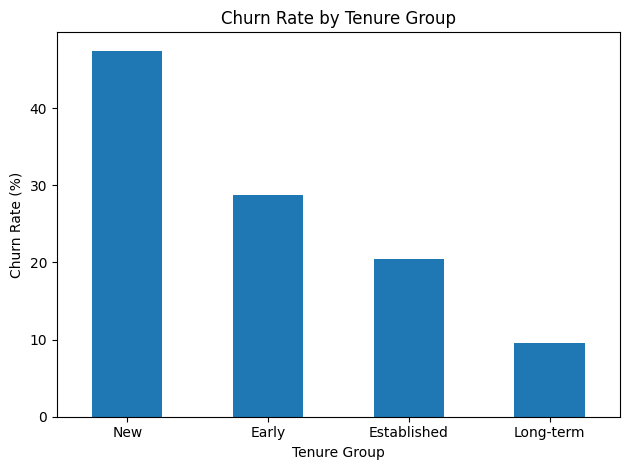

In [ ]:
churn_by_tenure.plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📄 Contract Analysis

In [ ]:
churn_by_contract = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_contract.round(2))

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


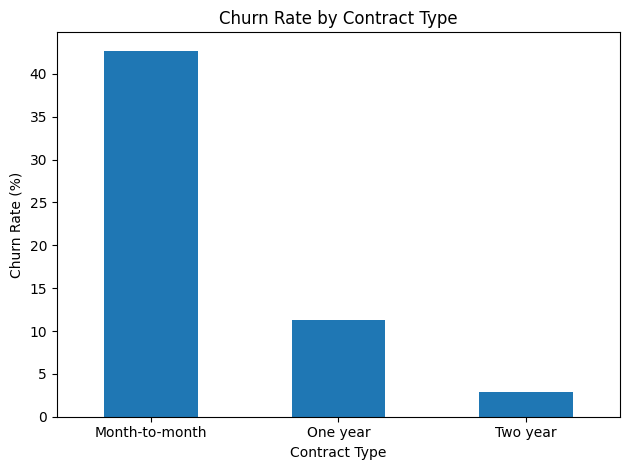

In [ ]:
churn_by_contract.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🌐 Internet Service Analysis

In [ ]:
churn_by_internet = df.groupby("InternetService")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_internet.round(2))

InternetService
DSL            18.96
Fiber optic    41.89
No              7.40
Name: Churn, dtype: float64


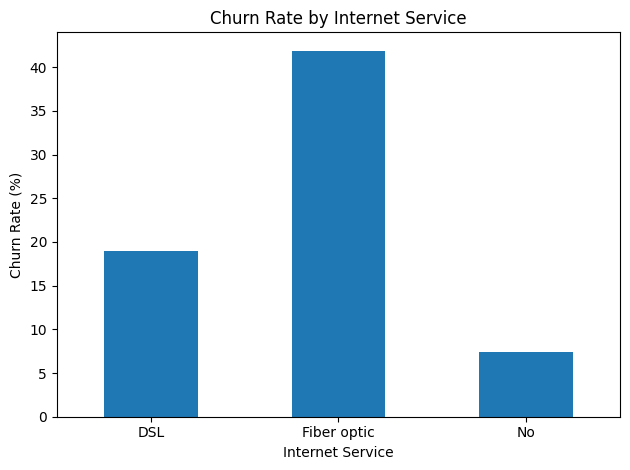

In [ ]:
churn_by_internet.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 💰 Monthly Charges Analysis

In [ ]:
monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

print(monthly_charges_churn.round(2))

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


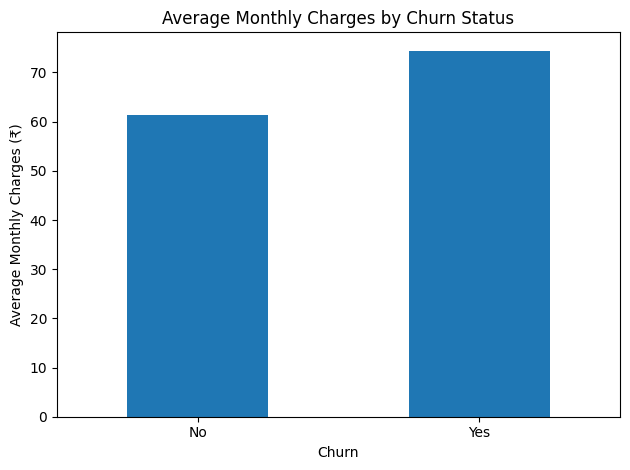

In [ ]:
monthly_charges_churn.plot(kind="bar")

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
churn_by_payment = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_payment.round(2))

PaymentMethod
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Electronic check             45.29
Mailed check                 19.11
Name: Churn, dtype: float64


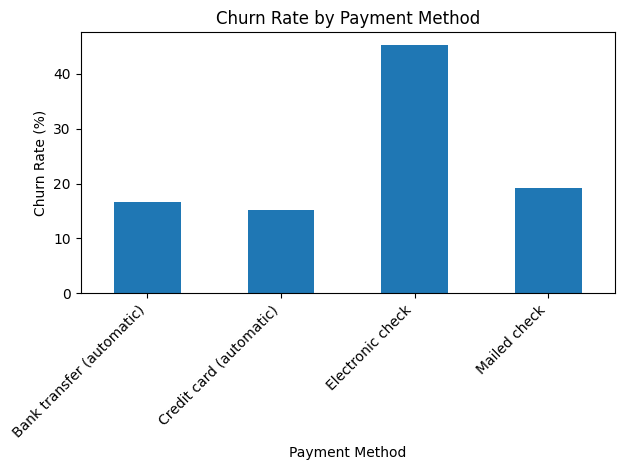

In [ ]:
churn_by_payment.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 👥 Senior Citizen Analysis

In [ ]:
churn_by_senior = df.groupby("SeniorCitizen")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_senior.round(2))

SeniorCitizen
0    23.61
1    41.68
Name: Churn, dtype: float64


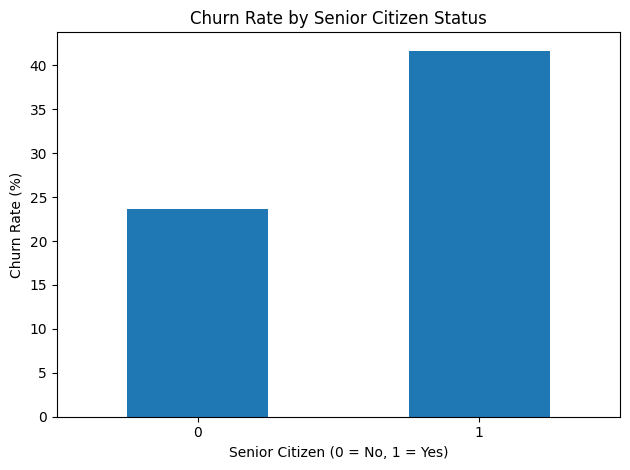

In [ ]:
churn_by_senior.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
churn_by_partner = df.groupby("Partner")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_partner.round(2))

Partner
No     32.96
Yes    19.66
Name: Churn, dtype: float64


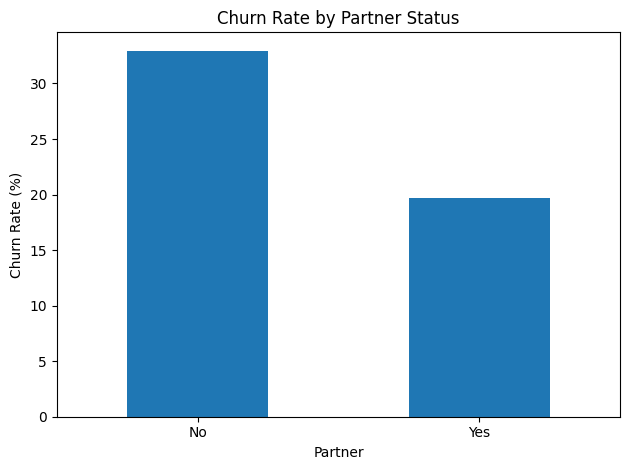

In [ ]:
churn_by_partner.plot(kind="bar")

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 👨‍👩‍👧 Dependents Analysis


In [ ]:
churn_by_dependents = df.groupby("Dependents")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_dependents.round(2))

Dependents
No     31.28
Yes    15.45
Name: Churn, dtype: float64


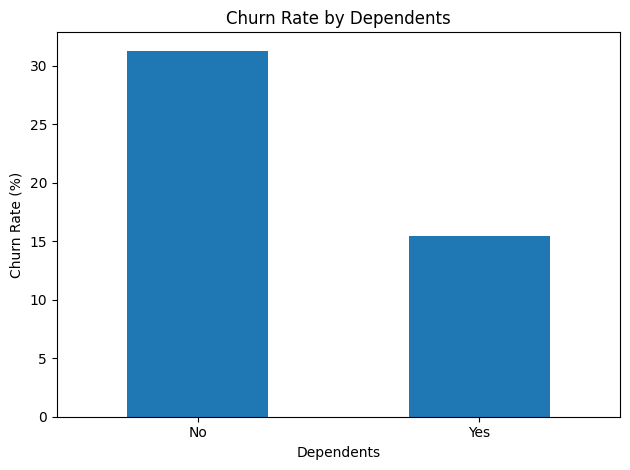

In [ ]:
churn_by_dependents.plot(kind="bar")

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🔎 Tenure and Contract Analysis

In [ ]:
churn_by_tenure_contract = df.groupby(
    ["TenureGroup", "Contract"],
    observed=True
)["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(churn_by_tenure_contract.round(2))

TenureGroup  Contract      
New          Month-to-month    51.35
             One year          10.48
             Two year           0.00
Early        Month-to-month    37.72
             One year           8.12
             Two year           0.00
Established  Month-to-month    32.92
             One year          10.62
             Two year           2.19
Long-term    Month-to-month    26.02
             One year          12.93
             Two year           3.33
Name: Churn, dtype: float64


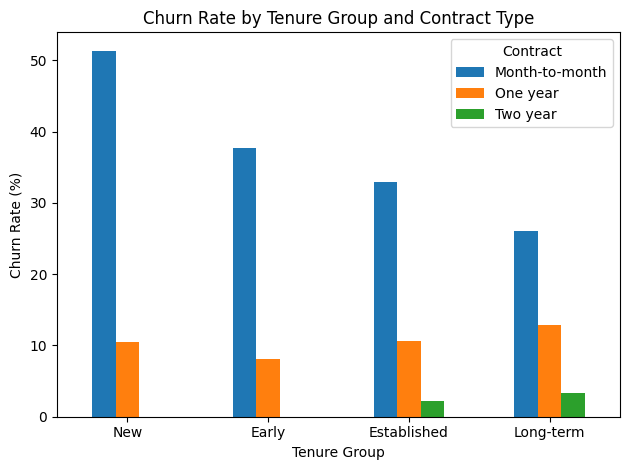

In [ ]:
churn_by_tenure_contract.unstack().plot(kind="bar")

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Contract")
plt.tight_layout()
plt.show()

## Key Business Insights


## Business Recommendations

1. Improve early customer retention

Focus on new customers during their first 12 months through onboarding support, proactive customer service, and early engagement campaigns, since this group has a 47.44% churn rate.

2. Encourage longer-term contracts

Provide suitable incentives or benefits for customers to move from month-to-month contracts to one-year or two-year contracts, because month-to-month customers have a 42.71% churn rate compared with 2.83% for two-year contracts.

3. Target the highest-risk segment

Create a dedicated retention campaign for new customers on month-to-month contracts, who have the highest observed churn rate of 51.35%.

4. Investigate fiber-optic customer dissatisfaction

Analyze complaints, service quality, pricing, outages, and customer support for fiber-optic customers before deciding on corrective actions, since this group has a 41.89% churn rate.

5. Investigate electronic-check customers

Examine why customers using electronic checks have a 45.29% churn rate and consider making alternative payment methods easier to adopt, while checking whether payment method is acting as a proxy for another customer characteristic.


# Conclusion

This customer churn analysis identified several factors associated with higher customer churn.

New customers had a much higher churn rate than long-term customers, while month-to-month contract customers also showed substantially higher churn than customers on longer contracts. Fiber optic customers and electronic-check users also showed higher observed churn rates.

The analysis suggests that the business should focus on improving early customer retention, encouraging longer-term contracts, investigating fiber-optic customer experience, and developing targeted retention strategies for high-risk customer segments.

These findings can help the business prioritize customer retention efforts and reduce potential customer loss.
